In [1]:
import jax
import jax.numpy as jnp
from matfree.lstsq import lsmr

In [2]:
#* helpers

def _key(x: int):
    return jax.random.PRNGKey(x)

def N(key, shape):
    return jax.random.normal(key, shape)

def random_spd(key, D):
    M = N(key, (D,D))
    return M@M.T

## Matrices and operators

- `A`: available as (also transposed) operator.
- `B`: available as std. and sqrt (both also transposed) operator.
- `C`: scaled identity, available as std. and sqrt operator.

In [3]:
D = 5
alpha = 1e-1

__A = random_spd(_key(123), D)
__B  = random_spd(_key(456), D)
__Bsqrt     = jnp.linalg.cholesky(__B)
__Bsqrt_inv = jnp.linalg.pinv(__Bsqrt)
y = jnp.zeros(1)
m = N(_key(789), (D,))

def A(v):
    return __A@v

def A_T(v):
    return __A.T@v

def C(v):
    return 1.0/alpha * v

def Csqrt(v):
    return 1.0/jnp.sqrt(alpha) * v

def Csqrt_inv(v):
    return jnp.sqrt(alpha) * v

def Bsqrt_inv(v):
    return __Bsqrt_inv @ v

def Bsqrt_inv_T(v):
    return __Bsqrt_inv.T @ v



def K(v):
    def vecmat(w):
        #*   √B⁻¹ A √C
        w1 = Bsqrt_inv_T(w)
        w2 = A_T(w1)
        w3 = Csqrt(w2)
        return w3
    solve = lsmr(atol=1e-3, btol=1e-3, ctol=1e-4)
    # solve = lsmr()
    u1 = Bsqrt_inv(v)
    xi, info = solve(vecmat, u1, damp=1.0)
    return Csqrt(xi)



#! for sanity checking
__K = __A.T@jnp.linalg.pinv(__A@__A.T / alpha + __B) / alpha

def K_cg(v):
    def matvec(w):
        #* Compute w -> (ACAᵀ + B) w
        w1 = A_T(w)
        w2 = C(w1)
        w3 = A(w2)
        return w3 + __B@w
    u1,*_ = jax.scipy.sparse.linalg.cg(matvec, v) #* Compute (ACAᵀ + B)⁻¹ v
    u2 = A_T(u1)
    u3 = C(u2)
    return u3

r1 = N(_key(117), (D,))
__K @ r1, \
K_cg(r1), \
K(r1),

(Array([-0.4933357 ,  0.5569575 ,  0.14237589, -0.37853613,  0.24854243],      dtype=float32),
 Array([-0.49333334,  0.556958  ,  0.14237507, -0.3785348 ,  0.2485427 ],      dtype=float32),
 Array([-0.49332964,  0.55696034,  0.14236774, -0.3785355 ,  0.24853346],      dtype=float32))

# Integration with GGN

In [4]:
from functools import partial

# @jax.jit
def H(p):
    """Closed-form loss Hessian of softmax."""
    return jnp.diag(p) - jnp.outer(p, p)
    
# @jax.jit
def Hsqrt(p):
    """Symmetric matrix S s.t. H = S Sᵀ"""
    q = jnp.sqrt(p)
    P = jnp.eye(p.size, dtype=p.dtype) - jnp.outer(q, q)
    S = q[:, None] * P
    return S

def Hsqrtsym(p, tol=1e-6):
    _H = H(p)
    E,V = jnp.linalg.eigh(_H)
    S = jnp.where(E > tol, jnp.sqrt(E), 0.0)
    return (V*S) @ V.T

# @partial(jax.jit, static_argnums=1)
def Hinvsqrt(p, tol=1e-6):
    _H = H(p)
    E,V = jnp.linalg.eigh(_H)
    S = jnp.where(E > tol, 1.0/jnp.sqrt(E), 0.0)
    return (V*S) @ V.T



key = jax.random.PRNGKey(44343)
p = jax.nn.softmax(jax.random.uniform(key, (5,)))
S = Hsqrt(p)
residual = H(p) - S @ S.T
# print(jnp.round(residual, 5))


In [5]:

### ! new

import jax
import jax.numpy as jnp

def _sym(A):  # numerical symmetrization
    return 0.5 * (A + A.T)

def _H_dense_from_probs(p):
    # p: [C]
    return jnp.diag(p) - jnp.outer(p, p)

def _H_roots_dense(p, *, rtol=1e-6):
    """
    Returns (H, H_sqrt, H_inv_sqrt) for a single probability vector p (C,).
    H_sqrt is the principal symmetric sqrt; H_inv_sqrt is the MP inverse sqrt.
    """
    H = _sym(_H_dense_from_probs(p))
    # EVD (symmetric, guaranteed real)
    w, U = jnp.linalg.eigh(H)                   # w ascending, U columns are eigenvectors
    # Threshold relative to the largest eigenvalue (handles rank C-1)
    wmax = jnp.maximum(w[-1], 0.)
    keep = w > (rtol * wmax)
    # Build sqrt and inv-sqrt on the kept subspace
    w_sqrt     = jnp.where(keep, jnp.sqrt(jnp.maximum(w, 0.)), 0.0)
    w_inv_sqrt = jnp.where(keep, 1.0 / jnp.sqrt(jnp.maximum(w, 0.)), 0.0)
    # Recompose via column scaling: U @ diag(d) @ U.T  == (U * d) @ U.T
    H_sqrt     = (U * w_sqrt) @ U.T
    H_inv_sqrt = (U * w_inv_sqrt) @ U.T
    # Optional: re-symmetrize tiny drifts
    return H, _sym(H_sqrt), _sym(H_inv_sqrt)

# Batched wrappers
_H_roots_dense_batched = lambda P1, rtol: jax.vmap(lambda P2: _H_roots_dense(P2, rtol=rtol))(P1)

def H_dense_batched(P, *, rtol=1e-4):
    H, _, _ = _H_roots_dense_batched(P, rtol=rtol)
    return H

def H_sqrt_dense_batched(P, *, rtol=1e-4):
    _, S, _ = _H_roots_dense_batched(P, rtol=rtol)
    return S

def H_inv_sqrt_dense_batched(P, *, rtol=1e-4):
    _, _, Si = _H_roots_dense_batched(P, rtol=rtol)
    return Si


In [6]:
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', False)

# load MAP state

import optax

from src.utils import load_checkpoint, load_yaml, count_model_params
from src.scalemodels import TrainState, EMPTY_STATS
from src.toymodels import SimpleClassifier
from src.toydata import get_dataloaders

dataset = 'banana'
model_name = f'toyclassifier_{dataset}'
cfg_path = f'config/toy/{model_name}.yml'

cfg = load_yaml(cfg_path)
model_cfg = cfg['model']
opt_cfg = cfg['optimization']
alpha =  opt_cfg["alpha"]
map_cfg = opt_cfg["map"]
full_set_size = opt_cfg["full_set_size"]

model_type = model_cfg.get("name", "regressor")  # 'regressor' or 'classifier'
num_h = model_cfg["num_h"]
num_l = model_cfg["num_l"]
num_c = model_cfg.get("num_c", 2) if model_type == "classifier" else 1
rng_model = jax.random.PRNGKey(model_cfg["seed"])
map_batch_size = map_cfg["batch_size"]
epochs_map = map_cfg["epochs"]
lr_map = map_cfg["lr"]

model = SimpleClassifier(numh=num_h, numl=num_l, numc=num_c)

train_loader, test_loader, _ = get_dataloaders(dataset=dataset, batch_size=map_batch_size)

dummy_input = next(iter(train_loader))[0][:1]
variables = model.init(rng_model, dummy_input)
optimizer_map = optax.adam(1e-3)
model_state = TrainState.create(
    apply_fn=model.apply,
    params=variables['params'],
    tx=optimizer_map,
    batch_stats = variables.get('batch_stats', EMPTY_STATS),
)
map_ckpt_prefix = f"map_{dataset}"

map_state = load_checkpoint(
    ckpt_dir="checkpoint/map/",
    prefix=map_ckpt_prefix,
    target=model_state
)

D = count_model_params(variables)

print(D)

[checkpoint] Loaded model checkpoint from /Users/nielsraunkjaer/Desktop/thesis/laplace-inducing-points/checkpoint/map (prefix=map_banana)
626


In [7]:
# compute W and GGN

from src.ggn import compute_W_vps, compute_ggn_vp, compute_ggn_dense
from src.utils import flatten_nn_params

flat_params, unravel_fn = flatten_nn_params(map_state.params)

REAL_DATA  = next(iter(train_loader))[0]
IP_DATA    = next(iter(train_loader))[0]

GGN_data_dense, *_ =  compute_ggn_dense(map_state, REAL_DATA, model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)
GGN_ip_dense, *_   =  compute_ggn_dense(map_state, IP_DATA,  model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)

GGN_data =  compute_ggn_vp(map_state, REAL_DATA,  model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)
GGN_ip   =  compute_ggn_vp(map_state, IP_DATA,   model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)
W, WT    =  compute_W_vps( map_state, REAL_DATA,   model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)
Wip, WTip=  compute_W_vps( map_state, IP_DATA, model_type=model_type, flat_params=flat_params, unravel_fn=unravel_fn, full_set_size=None)

beta      = full_set_size / IP_DATA.shape[0]
beta_sqrt = jnp.sqrt(beta)

from jax.flatten_util import ravel_pytree

flat_params, unravel_fn = ravel_pytree(map_state.params)

def get_f_apply(map_state, model_type):
    def f_apply(flatp, x):
        p = unravel_fn(flatp)
        if model_type == "regressor":
            return map_state.apply_fn(p, x, return_logvar=False)
        else:
            variables = {"params": p, "batch_stats": map_state.batch_stats}
            return map_state.apply_fn(variables, x, train=False, mutable=False)
    return f_apply

f_apply = get_f_apply(map_state, model_type)

print(REAL_DATA.shape)

(32, 2)


In [8]:

###*#################*###
###*                 *###
###* ASSERTION TESTS *###
###*                 *###
###*#################*###

v = jnp.ones(D,)

#* Obtain jvp output
f_out, y0 = jax.jvp(lambda _p: f_apply(_p, IP_DATA), (flat_params,), (v,))
#* Obtain vjp function
_, vj_fun = jax.vjp(lambda _p: f_apply(_p, IP_DATA), flat_params) # wildcard _ is same output as f_out of jvp call.

#* Compute loss Hessian
p1 = jax.nn.softmax(f_out, axis=1)
h1 = jax.vmap(H)(p1)

#* Batched matrix multiplication H @ (J v)
x1 = jnp.einsum('bij,bj->bi', h1, y0)
x2 = vj_fun(x1)[0]


assert jnp.all(
    jnp.isclose(x2, GGN_ip(v), atol=1e-7)
)

hsqrt1 = jax.vmap(Hsqrt)(p1)

y1 = jnp.einsum('bij,bi->bj', hsqrt1, y0)
x1 = jnp.einsum('bji,bi->bj', hsqrt1, y1)

x2 = vj_fun(x1)[0]

assert jnp.all(
    jnp.isclose(x2, GGN_ip(v), atol=1e-7)
)
x2, GGN_ip(v)

AssertionError: 

In [54]:
def get_lsmr_system(data, _alpha_inv_sqrt, v, *, beta_sqrt):
    f_out, vj_fun = jax.vjp(lambda _p: f_apply(_p, data), flat_params)
    p1 = jax.nn.softmax(f_out, axis=1)
    # S = jax.vmap(Hsqrt)(p1)
    # ST = jnp.einsum('bij->bji', S)
    S = jax.vmap(Hsqrtsym)(p1)
    ST = S
    Bm = beta_sqrt * S
    BmT = beta_sqrt * ST
    
    _, unravel_fn = ravel_pytree(v)
    
    def vecmat(_flat_vec):
        vec = unravel_fn(_flat_vec)
        x0 = jnp.einsum('bij,bj->bi', BmT, vec)
        x1 = vj_fun(x0)[0]
        x2,_ = ravel_pytree(x1)
        return _alpha_inv_sqrt * x2
    
    v0 = jnp.einsum('bij,bj->bi', Bm, v)
    flat_v0,_ = ravel_pytree(v0)
    
    return vecmat, flat_v0

# ! new
# def get_lsmr_system(data, _alpha_inv_sqrt, v, *, beta_sqrt):
#     f_out, vj_fun = jax.vjp(lambda _p: f_apply(_p, data), flat_params)
#     p1 = jax.nn.softmax(f_out, axis=1)                         # [B,C]
#     Hsqrt = H_sqrt_dense_batched(p1)                           # [B,C,C]
#     Bmhalf = beta_sqrt * Hsqrt                                 # sqrt(beta)*H^{1/2}

#     _, unravel_vec = ravel_pytree(v)

#     def vecmat(_flat_vec):
#         vec = unravel_vec(_flat_vec)                           # [B,C]
#         x0  = jnp.einsum('bij,bj->bi', Bmhalf, vec)           # H^{1/2} @ vec
#         x1  = vj_fun(x0)[0]                                   # J^T x0
#         x2, _ = ravel_pytree(x1)
#         return _alpha_inv_sqrt * x2

#     v0 = jnp.einsum('bij,bj->bi', Bmhalf, v)
#     flat_v0, _ = ravel_pytree(v0)
#     return vecmat, flat_v0




def get_K(_data, _alpha, _beta, *, atol=1e-3, btol=1e-3, ctol=1e-4):
    solve = lsmr(atol=atol, btol=btol, ctol=ctol)
    _alpha_inv_sqrt = jnp.sqrt(1.0 / _alpha)
    _beta_sqrt = jnp.sqrt(_beta)
    
    @jax.jit
    def K(v):
        vecmat, u1 = get_lsmr_system(_data, _alpha_inv_sqrt, v, beta_sqrt=_beta_sqrt)
        xi, info = solve(vecmat, u1, damp=1.0)
        return _alpha_inv_sqrt * xi
    
    return K

K = get_K(REAL_DATA, alpha, beta)
K(jax.random.normal(_key(12455), (REAL_DATA.shape))).shape

(626,)

In [64]:
def sample_theta(key, alpha, *, num_samples=1):
    alpha_inv_sqrt = jnp.sqrt(1.0 / alpha)
    return alpha_inv_sqrt * jax.random.normal(key, (num_samples, D))


def sample_logits_given_theta(key, theta0, real_data, *, beta):
    num_samples = theta0.shape[0]
    
    def linearized_fun(_t0):
        # Returns f(θ), Jθ_0
        _f_out,_jv = jax.jvp(
            lambda _p: f_apply(_p, real_data), (flat_params,), (_t0,)# - flat_params,)
        )
        return _f_out, _jv
    
    f_out, jv = jax.vmap(linearized_fun)(theta0)
    f_out = f_out[0] # since batch-dimension just means we have 'num_samples' copies
    
    p = jax.nn.softmax(f_out, axis=1)
    _Hinvsqrt = jax.vmap(Hinvsqrt)(p) / jnp.sqrt(beta)
    
    
    eps = jax.random.normal(key, (num_samples,) + f_out.shape)
    bmm1 = jnp.einsum("bij,nbj->nbi",_Hinvsqrt, eps)
    
    return bmm1 + jv




def get_conditional_theta_sampler(data, alpha, beta, *, atol=1e-3, btol=1e-3, ctol=1e-4):
    _K = get_K(data, alpha, beta, atol=atol, btol=btol, ctol=ctol)
    
    @partial(jax.jit, static_argnames=("num_samples",))
    def sample_theta_given_data(key, *, num_samples=1):
        key_theta, key_data = jax.random.split(key, 2)
        theta0 = sample_theta(key_theta, alpha, num_samples=num_samples)
        y0 = sample_logits_given_theta(key_data, theta0, data, beta=beta)
        # f_map = f_apply(flat_params, data)
        # residuals = f_map[None,...] - y0
        residuals = - y0
        return theta0 + jax.vmap(_K)(residuals)

    return sample_theta_given_data


theta_sampler = get_conditional_theta_sampler(IP_DATA, alpha, beta, atol=1e-6, btol=1e-6, ctol=1e-7)
theta_sampler(_key(49494), num_samples=3) # ! Execute once to JIT
print()

In [65]:
from tqdm import tqdm

num_means = 10
mean_sum = 0
key = _key(1234567)
for _k in tqdm(range(num_means)):
    keyi = jax.random.fold_in(key, _k)
    num_samples = 10_000

    alot_of_samples = theta_sampler(keyi, num_samples=num_samples)
    alot_of_samples#.block_until_ready()
    sample_mean = alot_of_samples.mean(axis=0)
    
    mean_sum += sample_mean
mean_mean = mean_sum / num_means

100%|██████████| 10/10 [00:34<00:00,  3.49s/it]


In [66]:
jnp.abs(mean_mean).mean()

Array(0.01574788, dtype=float32)

In [67]:
sample_mean = alot_of_samples.mean(axis=0, keepdims=True)
centered = (alot_of_samples - sample_mean)
sample_cov = centered.T @ centered / (num_samples - 1)
sample_precision = jnp.linalg.inv(sample_cov)
iso_prior = alpha * jnp.eye(D)
precision = iso_prior + beta*GGN_ip_dense
GGN_ip_inv_dense = jnp.linalg.inv(precision)
cov = GGN_ip_inv_dense
true_trace = jnp.linalg.trace((iso_prior + beta*GGN_data_dense) @ (GGN_ip_inv_dense))

In [68]:
jnp.round(       precision[:3,:3], 3), \
jnp.round(sample_precision[:3,:3], 3)

(Array([[206.44202  , -44.466003 , -59.319004 ],
        [-44.466003 ,  90.393005 ,   5.7330003],
        [-59.319004 ,   5.7330003,  70.972    ]], dtype=float32),
 Array([[221.908    , -47.743004 , -64.478004 ],
        [-47.672    ,  99.617004 ,   4.2640004],
        [-64.503006 ,   4.2980003,  76.115005 ]], dtype=float32))

In [69]:
_d = 5
jnp.round((precision - sample_precision) / precision, 3)[:_d,:_d]

Array([[-0.075     , -0.074     , -0.087     , -0.083     , -0.087     ],
       [-0.072     , -0.10200001,  0.256     , -0.134     , -0.15300001],
       [-0.087     ,  0.25      , -0.072     , -0.1       , -0.083     ],
       [-0.08400001, -0.133     , -0.1       , -0.08800001,  0.023     ],
       [-0.089     , -0.15300001, -0.08400001,  0.024     , -0.07      ]],      dtype=float32)

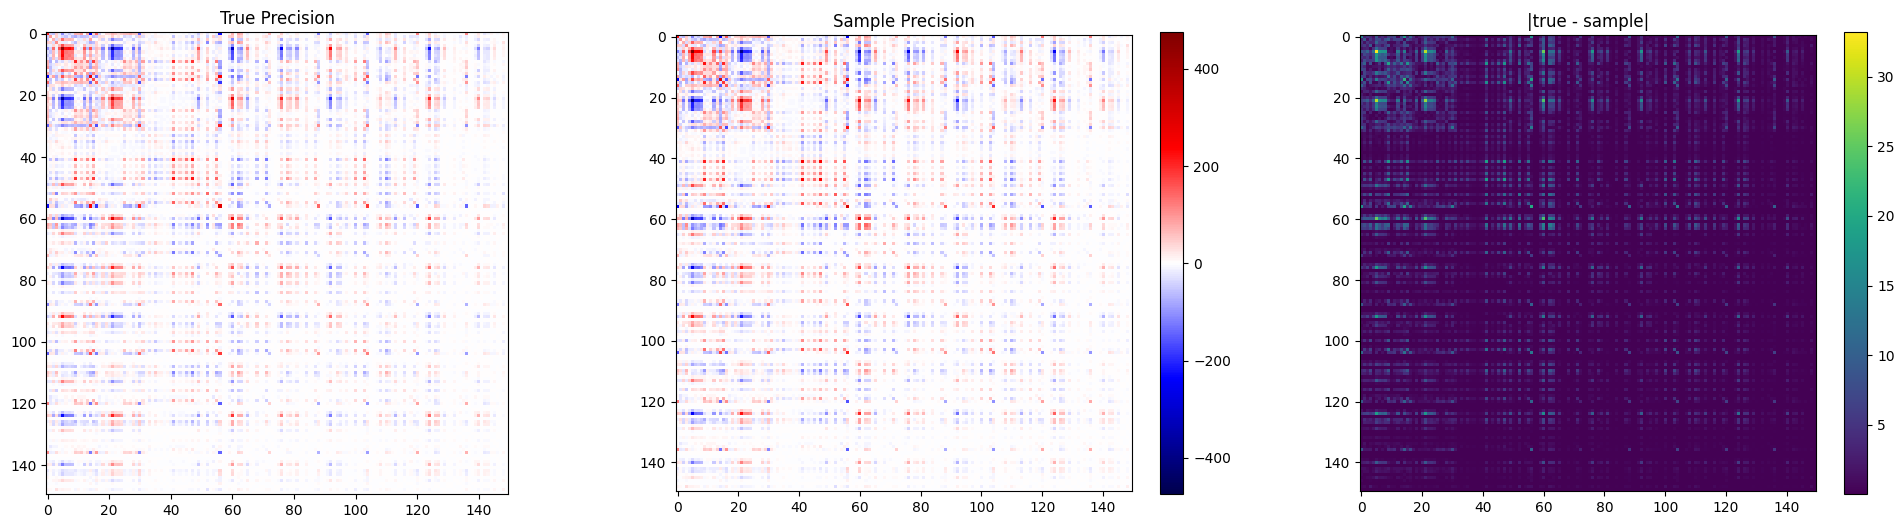

In [70]:
import matplotlib.pyplot as plt
from matplotlib import colors
# import seaborn as sns

cmap = 'seismic' #sns.color_palette('vlag', as_cmap=True)

_start = 0
_end   = 150
true_matrix =    precision[_start:_end, _start:_end] #cov[:_k,:_k]
sampled_matrix = sample_precision[_start:_end, _start:_end] #sample_cov[:_k,:_k]
diff = jnp.abs(true_matrix - sampled_matrix)# / (jnp.abs(true_matrix) + 1e-0)

fig, axs = plt.subplots(1, 3, figsize=(25, 6))

# Make limits symmetric so 0 is centered
m0 = jnp.abs(true_matrix).max()
m1 = jnp.abs(sampled_matrix).max()
norm  = colors.TwoSlopeNorm(vmin=-max(m0,m1), vcenter=0, vmax=max(m0,m1))
norm0 = norm # colors.TwoSlopeNorm(vmin=-m0, vcenter=0, vmax=m0)
norm1 = norm # colors.TwoSlopeNorm(vmin=-m1, vcenter=0, vmax=m1)

im0 = axs[0].imshow(true_matrix, cmap=cmap, norm=norm0)
im1 = axs[1].imshow(sampled_matrix, cmap=cmap, norm=norm1)
im2 = axs[2].imshow(diff, cmap='viridis')

axs[0].set_title("True Precision")
axs[1].set_title("Sample Precision")
axs[2].set_title("|true - sample|")

# fig.colorbar(im0)
fig.colorbar(im1)
fig.colorbar(im2)

plt.show()

In [71]:
from matfree import stochtrace

integrand = stochtrace.integrand_trace()
sampler = lambda __key: theta_sampler(__key, num_samples=10_000)
estimate = stochtrace.estimator(integrand, sampler)
est_trace = estimate(lambda v: alpha*v + beta*GGN_data(v), _key(88_88_88_88))

print(f"True trace    = {true_trace:.2f}")
print(f"Est. trace    = {est_trace:.2f}")

True trace    = 2503.78
Est. trace    = 2485.99


### Einsum stuff...


In [ ]:
d = 2
A = jnp.arange(1,int(d**2)+1).reshape(d,d)
b = jnp.ones(d)

# jnp.einsum('ab->ba', A)     # transpose
# jnp.einsum('ab,b->a', A, b) # A@b
# jnp.einsum('ba,b->a', A, b) # b.T @ A
jnp.einsum('ii->', A)         # trace(A)


Array(5, dtype=int32)